In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from tqdm import tqdm
import sys, os
sys.path.append(os.path.abspath("../../lib"))
import util
import importlib
importlib.reload(util)

<module 'util' from 'C:\\Users\\amand\\Documents\\Research\\Project_LIDI\\VAE_Tutorials\\lib\\util.py'>

# Introduction
### Motivation & model definition
Multi-layer VAEs extend the number of latent layers to 2 or more. Graphically, an L-layer VAE is the following Markov chain: $z_L - z_{L-1} - \dots - z_1 - x$. In this case, the posterior can be naively specified as $$q(z_1, \dots, z_L | x) = q(z_1|x) q(z_2|z_1) \dots q(z_L|z_{L-1})$$ while the prior is $p(z_1, \dots, z_L) = p(z_L) p(z_{L-1}|z_L) \dots p(z_1 | z_2)$. Note that only one term in the posterior depends on $x$, which makes it more prone to posterior collapse as the model depth increases.

Ladder VAE (LVAE), from "Ladder Variational Autoencoders" in 2016 by Sonderby et al, is an early innovation in deep, multi-layer VAE models that attempts to deal with posterior collapse by reorienting the posterior (encoder) to match the directionality of the prior (decoder). Notice in the naive decomposition of the posterior that the orientation of its terms compared to the prior are reversed, e.g. $q(z_L|z_{L-1})$ compared to $p(z_{L-1}|z_L)$. By simply rewriting the posterior in the opposite direction of the Markov chain, the deep layers in the posterior can continue to use the observed data $x$. Namely, $$q(z_1, \dots, z_L | x) = q(z_L|x) q(z_{L-1}|z_L, x) \dots q(z_1|z_2, x).$$

LVAE defines a deterministic upwards network that forms one half of the posterior distribution. The data $x$ passed upwards in each hierarchical level undergoes a deterministic transformation into $d_i$ through linear and activation layers before the output layer which produces $\hat{\mu}_i$ and $\hat{\sigma}_i$ parameters. The decoder parameters are found analogously to a standard VAE. However, each level involves sampling $z$ from the posterior distribution at that level, which is a compound distribution of the deterministic and previous prior parameters. Specifically at level $i$, $$z \sim q_i(z|x) \propto p^{det}_i(d_i) p^{dec}_i(z_i | z_{i+1})$$ where $p^{det}_i(d_i) = N(\hat{\mu}_i, \hat{\sigma}_i)$ is the distribution from the deterministic path and $p^{dec}_i(z_i | z_{i+1}) = N(\mu_{i, p}, \sigma_{i, p})$ is the prior distribution from the decoder. This allows the distribution of the encoder at each level to be explicitly tied to the observed data.

### Practical considerations
Reversal of the encoder Markov chain provides a useful inductive bias. Further, there are two key features of the LVAE model architecture that make training smoother. The first is a warm-up phase (also known as annealing) which linearly increases the contribution of the KL term in the ELBO from $0\%$ to $100\%$ across some number of epochs: $ELBO_{warm-up}(i) = \mathcal{L}_{recon} + \beta(i) \cdot \mathcal{L}_{KL}.$ This trick allows the objective to localize on a more stable part of the loss surface. The second feature is the addition of batch normalization layers that standardize the data per hidden layer. Excluding even one of these two features can result in exploding KL divergence. 

The model defined in this chapter is a close replica of the original LVAE model (LVAE trains for 2000 epochs but 20 epochs is enough for the purposes of this tutorial). We will perform ablation studies in the next chapters to compare performance to this baseline model.

# Setup

### MLP network

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.LeakyReLU(1e-2),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.LeakyReLU(1e-2)
        )

        self.mu = nn.Linear(hidden, out_dim)
        self.log_var = nn.Linear(hidden, out_dim)

    def forward(self, x, return_intermed=False):
        out = self.layers(x)

        output = []
        if return_intermed:
            output.append(out)
        output.append(self.mu(out))
        output.append(self.log_var(out))
        return output

### LVAE model

In [3]:
class LVAE(nn.Module):
    def __init__(self, kx, **kwargs):
        super().__init__()

        self.kx = kx

        # Default values are for original iVAE
        self.pz = kwargs.get('pz')
        self.num_hier = len(self.pz)  # number of hierarchical layers, must be at least 2
        self.hidden_dim = kwargs.get('hidden_dim')
        self.n_warmup = kwargs.get('n_warmup')  # number of epochs for KL loss annealing

        self.encoders = nn.ParameterList()
        self.decoders = nn.ParameterList()

        self.encoders.append(MLP(self.kx, self.pz[0], self.hidden_dim[0]))
        for i in range(1, self.num_hier):
            mlp_enc = MLP(self.hidden_dim[i - 1], self.pz[i], self.hidden_dim[i])
            self.encoders.append(mlp_enc)
            mlp_dec = MLP(self.pz[self.num_hier-i], self.pz[self.num_hier-i-1], self.hidden_dim[-i])
            self.decoders.append(mlp_dec)
        self.decoders.append(MLP(self.pz[0], self.kx, self.hidden_dim[0]))

    def forward(self, x):
        # hat = deterministic encoder layer, qs = stochastic encoder layer, ps = decoder layer
        mu_hats, mu_qs, mu_ps = [], [], []
        logvar_hats, logvar_qs, logvar_ps = [], [], []

        # === Encoder pass
        val = x
        for i in range(self.num_hier):
            val, mu_i_hat, logvar_i_hat = self.encoders[i](val, return_intermed=True)
            mu_hats.append(mu_i_hat)
            logvar_hats.append(logvar_i_hat)

        # === Reparameterization (last layer only)
        self.z = []
        z_val = util.sample(mu_hats[-1], logvar_hats[-1])
        self.z.append(z_val)

        # === Decoder pass
        # Add q(z_L|x)
        mu_qs.append(mu_hats[-1])
        logvar_qs.append(logvar_hats[-1])
        # Add prior p(z_L) ~ N(0, I)
        mu_ps.append(torch.zeros_like(z_val))
        logvar_ps.append(torch.zeros_like(z_val))

        for i in range(self.num_hier):
            # Get p(z_i|z_i+1) or p(x|z_1)
            mu_p, logvar_p = self.decoders[i](z_val)
            mu_ps.append(mu_p)
            logvar_ps.append(logvar_p)

            if i < self.num_hier-1:
                # Construct compound distribution
                idx = self.num_hier - i - 2  # iterate backwards on (mu_hat, logvar_hat), exclude first set outside loop
                mu_q, logvar_q = util.compound_normal(mu_hats[idx], logvar_hats[idx], mu_p, logvar_p)
                mu_qs.append(mu_q)
                logvar_qs.append(logvar_q)
                # Sample
                z_val = util.sample(mu_q, logvar_q)
                self.z.append(z_val)

        return mu_hats, logvar_hats, mu_qs, logvar_qs, mu_ps, logvar_ps

    def loss(self, x, params, beta=1):
        mu_hats, logvar_hats, mu_qs, logvar_qs, mu_ps, logvar_ps = params

        recon = -1 * util.normal_ll(x, mu_ps[-1], logvar_ps[-1])
        kl_div = 0
        kl_per_hier = []
        for i in range(self.num_hier):
            kl = util.kl_normal(mu_qs[i], logvar_qs[i], mu_ps[i], logvar_ps[i])
            kl_per_hier.append(kl.mean())
            kl_div += kl
        return recon.mean(), beta * kl_div.mean(), kl_per_hier

    def anneal(self, iteration):
        if self.n_warmup <= 0:
            return 1
        beta = np.min([iteration / self.n_warmup, 1])
        return beta

    def get_z_samples(self):
        return self.z

# Training

### Prepare for training

In [4]:
# Load CPU or GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA


In [5]:
# Training & model settings
cfg = {
    'rng': 1,
    'batch_size': 256,
    'epochs': 20,
    'lr': 0.0001,
    'n_warmup': 3,
    'data_src': 'MNIST',
    'pz': [64, 32, 16],
    'hidden_dim': [256, 128, 64]
}

# Set random seed
torch.manual_seed(cfg['rng'])
np.random.seed(cfg['rng'])

In [6]:
# Load dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data))

### Training loop

In [7]:
model = LVAE(kx, **cfg).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
n_parameters = sum(param.numel() for param in model.parameters())
print("Number of parameters: " + str(n_parameters))

recon, kl, kl_hier, metrics = util.train_lvae(model, optimizer, train_loader, device, **cfg)

Number of parameters: 907456


100%|██████████| 20/20 [01:08<00:00,  3.42s/it]


# Evaluation

### Plot overall training loss

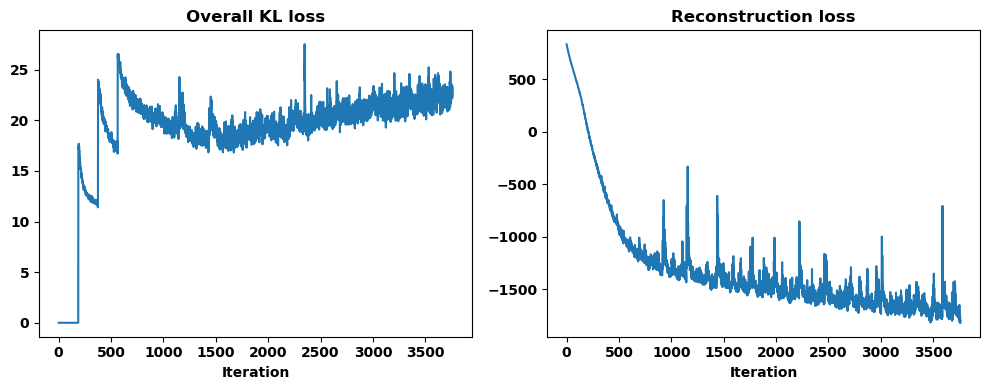

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Overall KL loss
axs[0].plot(kl)
axs[0].set_xlabel("Iteration")
axs[0].set_title("Overall KL loss")
# Reconstruction loss
axs[1].plot(recon)
axs[1].set_xlabel("Iteration")
axs[1].set_title("Reconstruction loss")
plt.tight_layout()

### Plot KL loss per hierarchy

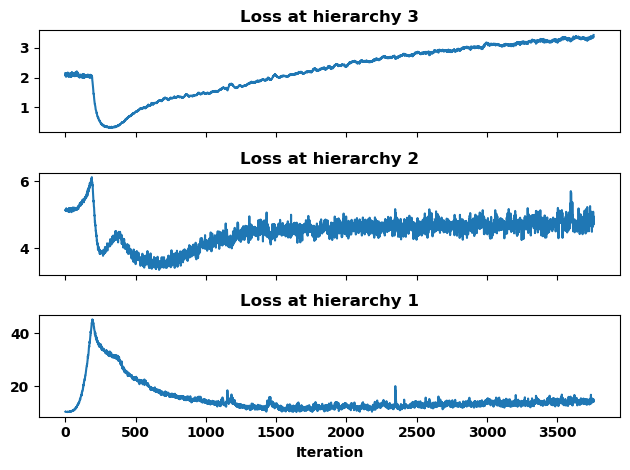

In [9]:
num_hier = kl_hier.shape[1]
fig, axs = plt.subplots(nrows=num_hier, ncols=1, sharex=True)

for i in range(num_hier):
    axs[i].plot(kl_hier[:, i], label="Level "+str(i))
    axs[i].set_title("Loss at hierarchy " + str(num_hier-i))
axs[i].set_xlabel("Iteration")
plt.tight_layout()

### Plot mutual information

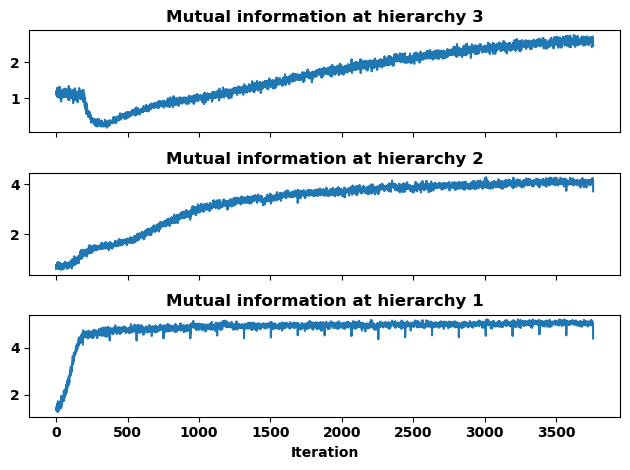

In [10]:
fig, axs = plt.subplots(nrows=num_hier, ncols=1, sharex=True)
ami_arr = np.array(metrics['ami'])

for i in range(num_hier):
    axs[i].plot(ami_arr[:, i], label="Level "+str(i))
    axs[i].set_title("Mutual information at hierarchy " + str(num_hier-i))
axs[i].set_xlabel("Iteration")
plt.tight_layout()

### Plot active units

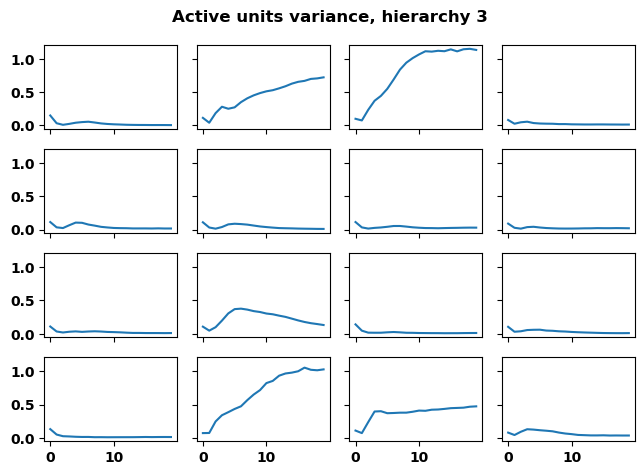

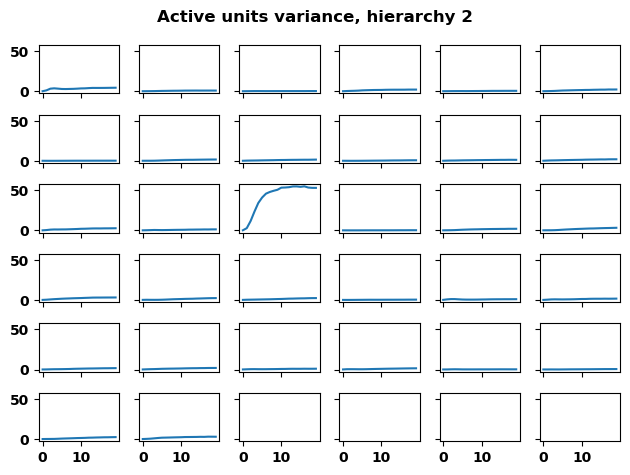

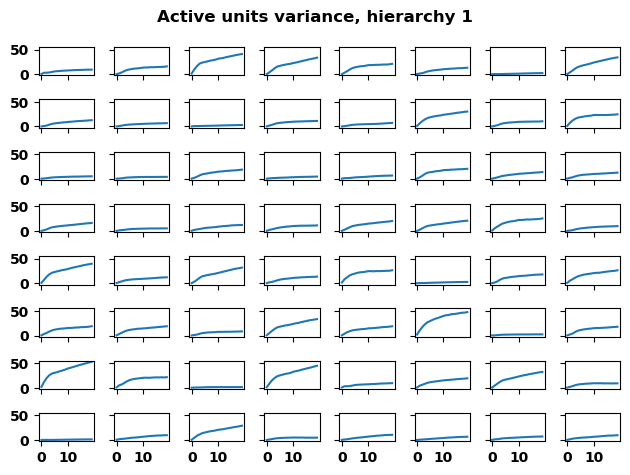

In [11]:
au_lst = metrics['au']
num_hier = len(au_lst)
for ii in range(num_hier):
    au_ii = au_lst[ii]
    dim_ii = au_ii.shape[1]
    n_subplt = int(np.ceil(np.sqrt(dim_ii)))
    fig, axs = plt.subplots(nrows=n_subplt, ncols=n_subplt, sharex=True, sharey=True)
    for jj in range(dim_ii):
        r, c = np.unravel_index(jj, (n_subplt, n_subplt))
        axs[r, c].plot(au_ii[:, jj])
    plt.suptitle("Active units variance, hierarchy " + str(num_hier-ii))
    plt.tight_layout()

### Evaluation on test data

In [12]:
model.eval()
with torch.no_grad():
    for batch in test_loader:
        x, u = util.get_batch(batch, cfg['data_src'], device)
        output = model(x)

### Plot 2d PCA representation per hierarchy

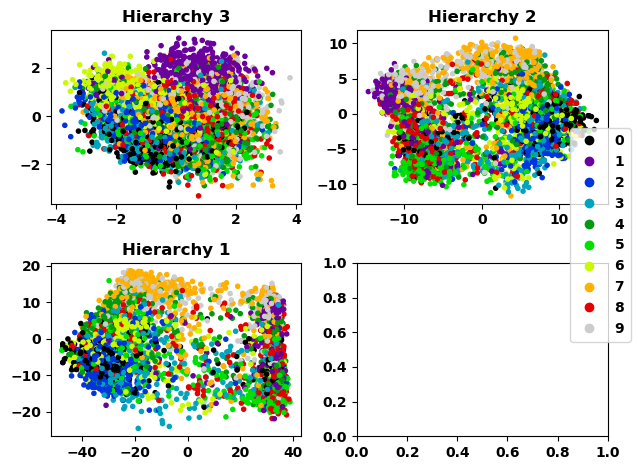

In [13]:
zs = model.get_z_samples()
titles = ["Hierarchy 3", "Hierarchy 2", "Hierarchy 1"]
u = u.detach().cpu()
util.plot_multiple_pca(zs, lbls=u, title_lst=titles)